In [1]:
import pandas as pd
import numpy as np
import os

# ==============================================================================
# 1. CHARGEMENT DES DONNÉES (Le fichier est au niveau parent direct)
# ==============================================================================
# On remonte d'un dossier (..) pour arriver dans Projet_EDA_RFM où se trouve data.csv
path_data = os.path.join('..', 'data.csv')

try:
    df = pd.read_csv(path_data, encoding='ISO-8859-1')
    print(f" Succès ! Dataset original chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
    
    # ==============================================================================
    # 2. DATA CLEANING (Uniquement si le chargement réussit)
    # ==============================================================================
    df_clean = df.copy()

    # A. Supprimer les lignes où le CustomerID est manquant
    df_clean = df_clean.dropna(subset=['CustomerID'])
    df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

    # B. Filtrer les anomalies (Quantités et prix strictement positifs)
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

    # C. Convertir la colonne de date en vrai format Datetime
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

    # ==============================================================================
    # 3. FEATURE ENGINEERING
    # ==============================================================================
    # A. Variable Business : Montant total
    df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

    # B. Variables temporelles
    df_clean['Year'] = df_clean['InvoiceDate'].dt.year
    df_clean['Month'] = df_clean['InvoiceDate'].dt.month
    df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
    df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

    print(f"Nettoyage & Feature Engineering réussis ! Lignes restantes : {df_clean.shape[0]}")
    print(f"Lignes supprimées : {df.shape[0] - df_clean.shape[0]}\n")

    print("--- Aperçu du Dataset Nettoyé (df_clean) ---")
    display(df_clean[['InvoiceNo', 'CustomerID', 'TotalAmount', 'Month', 'DayOfWeek', 'Hour']].head())

except FileNotFoundError:
    print(f"Erreur : Le fichier 'data.csv' est introuvable au chemin : {os.path.abspath(path_data)}")
    print("Vérifie si tu as déplacé le fichier ou s'il a un autre nom.")

 Succès ! Dataset original chargé : 541909 lignes, 8 colonnes.
Nettoyage & Feature Engineering réussis ! Lignes restantes : 397884
Lignes supprimées : 144025

--- Aperçu du Dataset Nettoyé (df_clean) ---


,InvoiceNo,CustomerID,TotalAmount,Month,DayOfWeek,Hour
0,536365,17850,15.30,12,Wednesday,8
1,536365,17850,20.34,12,Wednesday,8
2,536365,17850,22.00,12,Wednesday,8
3,536365,17850,20.34,12,Wednesday,8
4,536365,17850,20.34,12,Wednesday,8


C:\Users\GUERRAB AOUATIF\AppData\Local\Temp\ipykernel_24852\4275659149.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='TotalAmount', data=monthly_sales, palette='Blues_r')


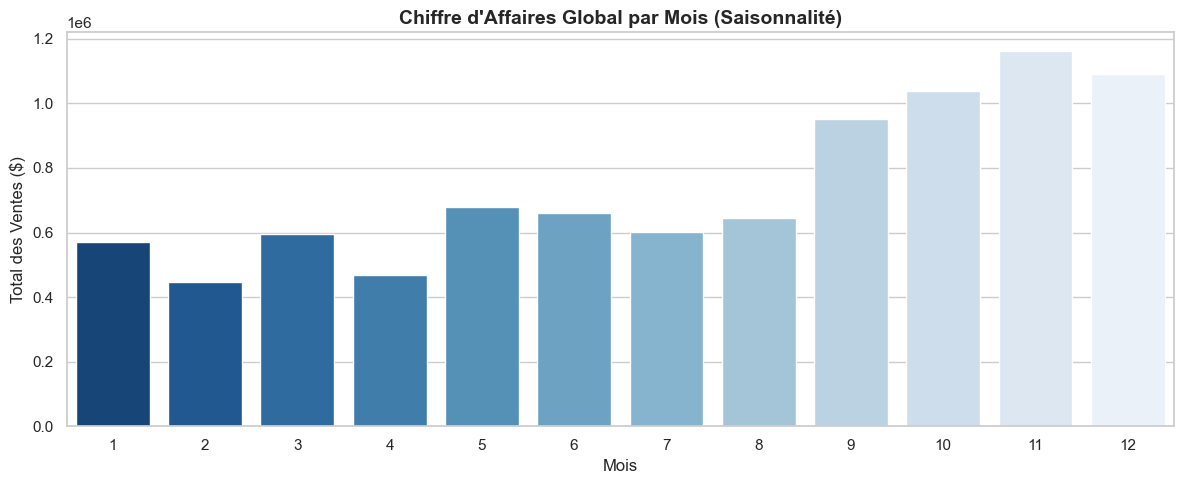

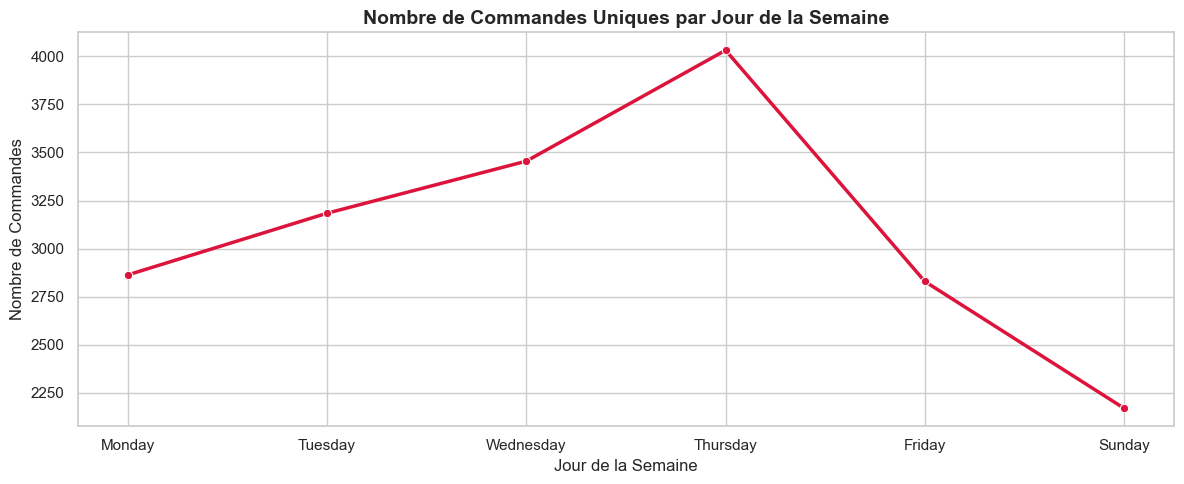

C:\Users\GUERRAB AOUATIF\AppData\Local\Temp\ipykernel_24852\4275659149.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hour', y='InvoiceNo', data=hourly_orders, palette='viridis')


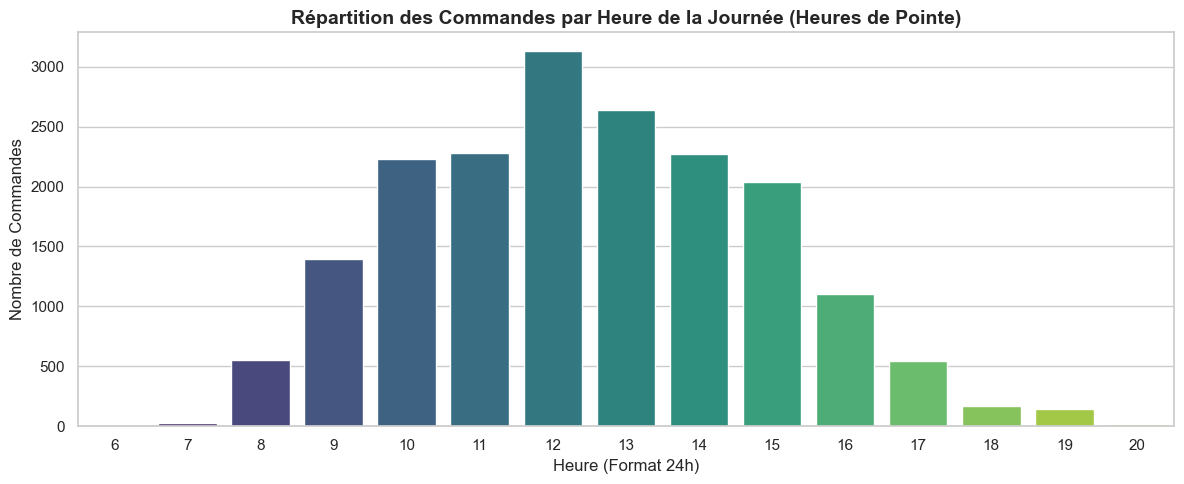

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ==============================================================================
# 1. ÉVOLUTION DU CHIFFRE D'AFFAIRES PAR MOIS
# ==============================================================================
plt.figure()
monthly_sales = df_clean.groupby('Month')['TotalAmount'].sum().reset_index()
sns.barplot(x='Month', y='TotalAmount', data=monthly_sales, palette='Blues_r')
plt.title("Chiffre d'Affaires Global par Mois (Saisonnalité)", fontsize=14, fontweight='bold')
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Total des Ventes ($)", fontsize=12)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. DISTRIBUTION DES COMMANDES PAR JOUR DE LA SEMAINE
# ==============================================================================
plt.figure()
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] # Note: Samedi est souvent absent dans ce dataset uci
day_counts = df_clean.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(order_days).reset_index()

sns.lineplot(x='DayOfWeek', y='InvoiceNo', data=day_counts, marker='o', color='crimson', linewidth=2.5)
plt.title("Nombre de Commandes Uniques par Jour de la Semaine", fontsize=14, fontweight='bold')
plt.xlabel("Jour de la Semaine", fontsize=12)
plt.ylabel("Nombre de Commandes", fontsize=12)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. ANALYSE DES HEURES DE POINTE (Tranches Horaires)
# ==============================================================================
plt.figure()
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique().reset_index()
sns.barplot(x='Hour', y='InvoiceNo', data=hourly_orders, palette='viridis')
plt.title("Répartition des Commandes par Heure de la Journée (Heures de Pointe)", fontsize=14, fontweight='bold')
plt.xlabel("Heure (Format 24h)", fontsize=12)
plt.ylabel("Nombre de Commandes", fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
import datetime as dt

# 1. Définir la date de référence (le lendemain de la dernière transaction du dataset)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Date de référence pour le calcul : {snapshot_date.strftime('%Y-%m-%d')}\n")

# 2. Grouper par client pour calculer les métriques R, F, M
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Récence (Jours)
    'InvoiceNo': 'nunique',                                   # Fréquence (Nb de commandes)
    'TotalAmount': 'sum'                                      # Montant ($)
})

# Renommer les colonnes pour faire propre
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("--- Aperçu des métriques RFM brutes par client ---")
display(rfm.head())

Date de référence pour le calcul : 2011-12-10

--- Aperçu des métriques RFM brutes par client ---


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [4]:
# 1. Calculer les scores par quintiles (de 1 à 5)
# Pour la récence, plus c'est petit, mieux c'est (on inverse les labels)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Pour la fréquence, il peut y avoir des doublons sur les petites valeurs, on utilise 'rank' si besoin ou 'drop'
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 2. Créer le Score RFM Combiné (Texte) et Global (Somme ou Concaténation)
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("--- Métriques RFM avec Scoring Réussi ---")
display(rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment']].head())

--- Métriques RFM avec Scoring Réussi ---


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [5]:
# Fonction pour mapper les scores en segments logiques
def nommer_segment(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions (Top Clients)'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk (Churn High)'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Intermédiaire / Prometteurs'

# Appliquer la fonction
rfm['Segment_Business'] = rfm.apply(nommer_segment, axis=1)

# Voir la répartition des clients par segment
print("--- Répartition de nos clients par Segment Business ---")
print(rfm['Segment_Business'].value_counts())

--- Répartition de nos clients par Segment Business ---
Segment_Business
Champions (Top Clients)        1139
Lost Customers                 1065
Loyal Customers                 821
Intermédiaire / Prometteurs     719
New Customers                   319
At Risk (Churn High)            275
Name: count, dtype: int64


In [6]:
# 1. Joindre le segment de chaque client avec ses transactions d'origine
df_final = df_clean.merge(rfm[['Segment_Business']], on='CustomerID', how='left')

# 2. Sauvegarder la table finale des transactions segmentées
path_export_transactions = os.path.join('..', 'data', 'ecommerce_segmented_transactions.csv')
df_final.to_csv(path_export_transactions, index=False)

# 3. Sauvegarder aussi la table profil des clients uniques (RFM)
path_export_rfm = os.path.join('..', 'data', 'customer_rfm_scores.csv')
rfm.to_csv(path_export_rfm, index=True)

print(" Les fichiers de données sont prêts pour Power BI / Tableau !")
print(f"1. Fichier Transactions : {path_export_transactions}")
print(f"2. Fichier Profils RFM : {path_export_rfm}")

 Les fichiers de données sont prêts pour Power BI / Tableau !
1. Fichier Transactions : ..\data\ecommerce_segmented_transactions.csv
2. Fichier Profils RFM : ..\data\customer_rfm_scores.csv


In [8]:
# Force l'exportation avec la virgule comme séparateur décimal pour Windows/Power BI Français
path_export_transactions_fr = os.path.join('..', 'data', 'ecommerce_segmented_transactions.csv')

# On force explicitement le séparateur de colonne (semicolon ;) et le séparateur décimal (comma ,)
df_final.to_csv(path_export_transactions_fr, index=False, sep=';', decimal=',')

print("Fichier recréé avec SUCCÈS au format idéal pour ton PC !")

Fichier recréé avec SUCCÈS au format idéal pour ton PC !


In [9]:
# 1. Mélanger les transactions avec le Segment ET la Recency du client
df_final = df_clean.merge(rfm[['Segment_Business', 'Recency']], on='CustomerID', how='left')

# 2. Ré-exporter le fichier proprement avec le bon format pour ton PC
path_export_transactions_fr = os.path.join('..', 'data', 'ecommerce_segmented_transactions.csv')
df_final.to_csv(path_export_transactions_fr, index=False, sep=';', decimal=',')

print("Succès ! Le fichier a été mis à jour avec la colonne Recency !")

Succès ! Le fichier a été mis à jour avec la colonne Recency !
